## Assignment: $k$ Means Clustering


**Q1.** This is a question about clustering. We want to investigate how adjusting the "noisiness" of the data impacts the quality of the algorithm and the difficulty of picking $k$.

1. Run the code below, which creates four datasets: `df0_125`, `df0_25`, `df0_5`, `df1_0`, and `df2_0`. Each data set is created by increasing the amount of `noise` (standard deviation) around the cluster centers, from `0.125` to `0.25` to `0.5` to `1.0` to `2.0`.

```
import numpy as np
import pandas as pd

def createData(noise,N=50):
    np.random.seed(100) # Set the seed for replicability
    # Generate (x1,x2,g) triples:
    X1 = np.array([np.random.normal(1,noise,N),np.random.normal(1,noise,N)])
    X2 = np.array([np.random.normal(3,noise,N),np.random.normal(2,noise,N)])
    X3 = np.array([np.random.normal(5,noise,N),np.random.normal(3,noise,N)])
    # Concatenate into one data frame
    gdf1 = pd.DataFrame({'x1':X1[0,:],'x2':X1[1,:],'group':'a'})
    gdf2 = pd.DataFrame({'x1':X2[0,:],'x2':X2[1,:],'group':'b'})
    gdf3 = pd.DataFrame({'x1':X3[0,:],'x2':X3[1,:],'group':'c'})
    df = pd.concat([gdf1,gdf2,gdf3],axis=0)
    return df

df0_125 = createData(0.125)
df0_25 = createData(0.25)
df0_5 = createData(0.5)
df1_0 = createData(1.0)
df2_0 = createData(2.0)
```

2. Make scatterplots of the $(X1,X2)$ points by group for each of the datasets. As the `noise` goes up from 0.125 to 2.0, what happens to the visual distinctness of the clusters?
3. Create a scree plot for each of the datasets. Describe how the level of `noise` affects the scree plot (particularly the presence of a clear "elbow") and your ability to definitively select a $k$. (Pay attention to the vertical axis across plots, or put all the scree curves on a single canvas.)
4. Explain the intuition of the elbow, using this numerical simulation as an example.

**Q2.** This question is a case study on clustering.

1. Load the `SIPRI Military Expenditure Database.csv` file in the `./data` folder. This has data about military spending by country. Filter the rows to select only the year 2020, and drop all rows with missing values. I ended up with 148 countries. Is any further cleaning of the variables required?
2. Max-min normalize `Spending (2020 USD)` and `Spending per Capita`. Use a scree plot to determine the optimal number of clusters for the $k$ means clustering algorithm. Make a scatter plot of `Spending (2020 USD)` and `Spending per Capita`, and hue the dots by their cluster membership. Compute a describe table conditional on cluster membership (i.e. `.groupby(cluster).describe()`). What do you see? Where is the United States? Do you notice any patterns in the cluster membership?
3. Repeat part 2 for `Percent of Government Spending` and `Percent of GDP`. How do your results compare to part 2?
4. Use $k$ means clustering with all four numeric variables: `Spending (2020 USD)`, `Spending per Capita`, `Percent of Government Spending`, and `Percent of GDP`. How do your results compare to the previous two parts?
5. Did the $k$-MC algorithm find any useful patterns for you in analyzing the spending?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Matthew Calvario

**Date:** 10/09/26

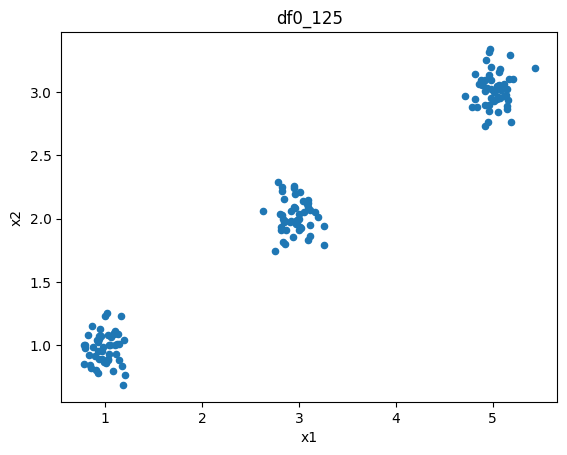

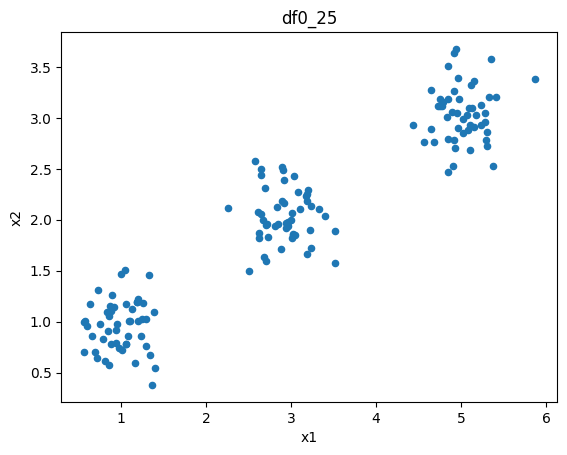

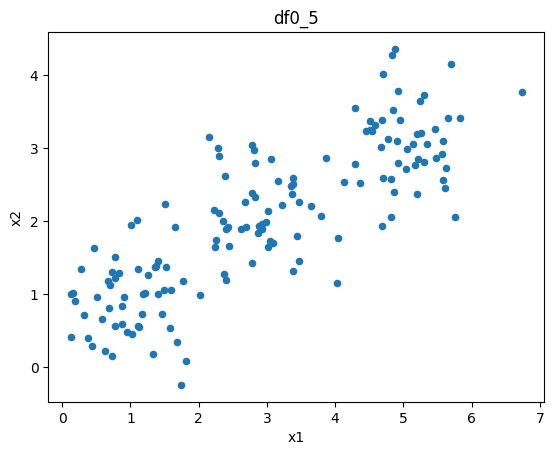

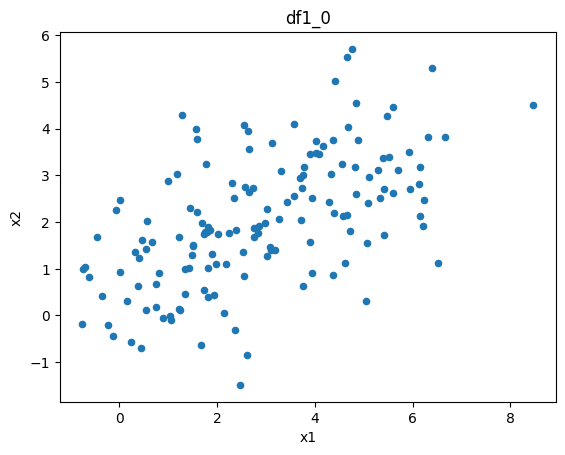

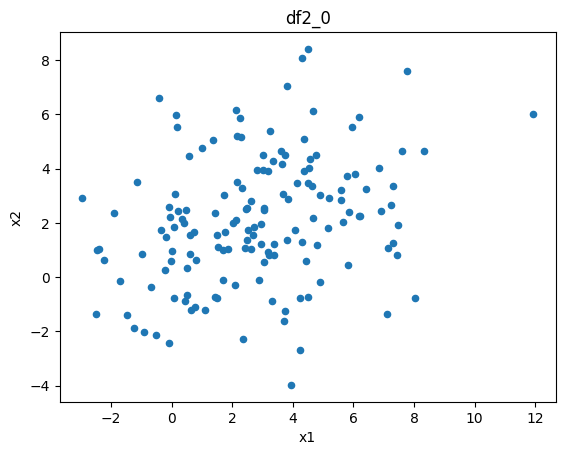


Looking at the scatterplots, the visual distinctness of the clusters diminishes
as the amount of noise in the dataset increases from 0.125 to 2.0. In other words,
the points become more dispersed rather than concentrated, making each individual cluster
harder to distinguish from the other.



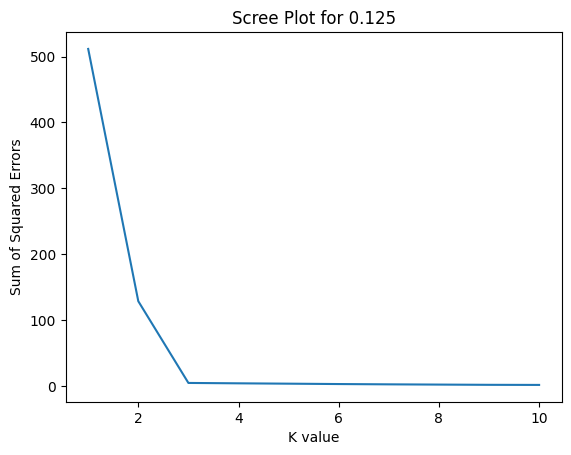

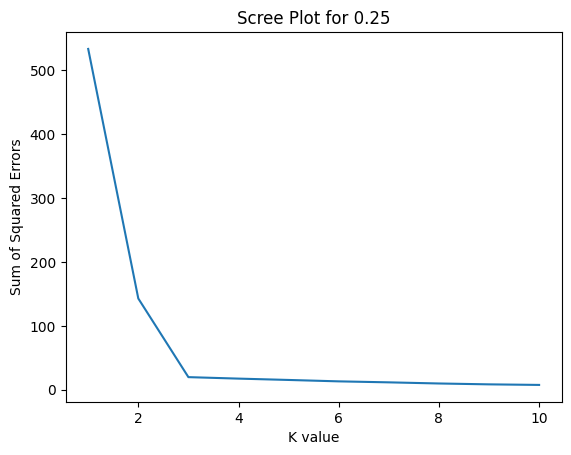

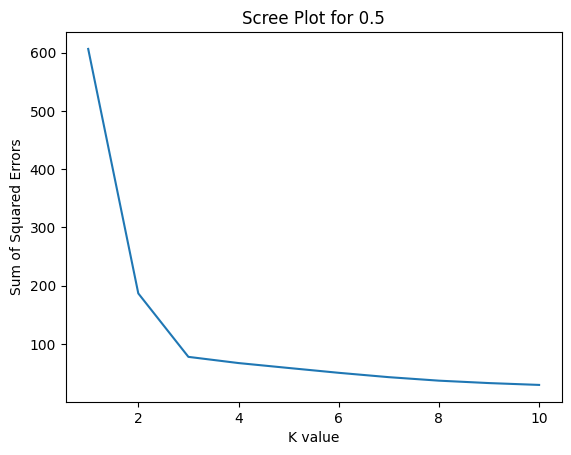

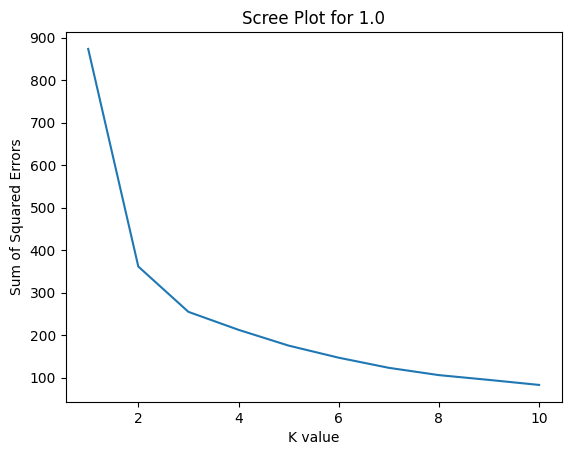

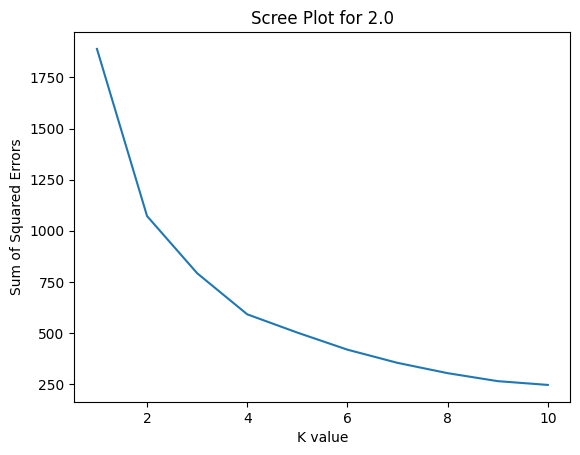


As seen from the scree plots, higher levels of noise make an eblow point less discernable,
with each line plot becoming smoother around the drop-off zone (i.e. the point(s) on the line
at which the SSE drastically drops) from 0.125 to 2.0 noise. For example, at Noise level 0.125,
the elbow is almost certainly located at k = 3. Conversely, the elbow point for Noise Level 2.0
could be any k-value between 3 and 5--this is because there is not as harsh of an inflection point
for decrease in SSE, making it harder to select which of them would be the most correct candidate.


The elbow point signals a k-value when decreases in error, more specifically SSE, for a given set of k-values
drastically slows down. For example, in the numerical simulations above, elbow points would be the following
k-values:
  - 0.125: 3
  - 0.25: 3
  - 0.5: 3
  - 1.0: 3 or 4
  - 2.0: 3,4 or 5
matching these values to the graphs, one can see that these points represent when the SSE--the y-axis--continues to derease

In [3]:
# Your Phase 1 solution to the problem goes here.

# QUESTION 1

# Q1.1
import numpy as np
import pandas as pd

def createData(noise,N=50):
    np.random.seed(100) # Set the seed for replicability
    # Generate (x1,x2,g) triples:
    X1 = np.array([np.random.normal(1,noise,N),np.random.normal(1,noise,N)])
    X2 = np.array([np.random.normal(3,noise,N),np.random.normal(2,noise,N)])
    X3 = np.array([np.random.normal(5,noise,N),np.random.normal(3,noise,N)])
    # Concatenate into one data frame
    gdf1 = pd.DataFrame({'x1':X1[0,:],'x2':X1[1,:],'group':'a'})
    gdf2 = pd.DataFrame({'x1':X2[0,:],'x2':X2[1,:],'group':'b'})
    gdf3 = pd.DataFrame({'x1':X3[0,:],'x2':X3[1,:],'group':'c'})
    df = pd.concat([gdf1,gdf2,gdf3],axis=0)
    return df

df0_125 = createData(0.125)
df0_25 = createData(0.25)
df0_5 = createData(0.5)
df1_0 = createData(1.0)
df2_0 = createData(2.0)

# Q1.2
import matplotlib.pyplot as plt

df0_125.plot.scatter(x='x1', y='x2', title =  "df0_125")
plt.show()
df0_25.plot.scatter(x='x1', y='x2', title =  "df0_25")
plt.show()
df0_5.plot.scatter(x='x1', y='x2', title =  "df0_5")
plt.show()
df1_0.plot.scatter(x='x1', y='x2', title =  "df1_0")
plt.show()
df2_0.plot.scatter(x='x1', y='x2', title =  "df2_0")
plt.show()

print("""
Looking at the scatterplots, the visual distinctness of the clusters diminishes
as the amount of noise in the dataset increases from 0.125 to 2.0. In other words,
the points become more dispersed rather than concentrated, making each individual cluster
harder to distinguish from the other.
""")

# Q1.3
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Drop group column because it is non-numeric and rename dataset to X_i
X_1 = df0_125.drop(columns=["group"])
X_2 = df0_25.drop(columns=["group"])
X_3 = df0_5.drop(columns=["group"])
X_4 = df1_0.drop(columns=["group"])
X_5 = df2_0.drop(columns=["group"])

# 0.125
ks = np.arange(1,11)
SSE = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_1).inertia_
    for k in ks
]

plt.figure()
sns.lineplot(x=ks, y=SSE)
plt.xlabel("K value")
plt.ylabel("Sum of Squared Errors")
plt.title("Scree Plot for 0.125")
plt.show()

# 0.25
ks = np.arange(1,11)
SSE = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_2).inertia_
    for k in ks
]

plt.figure()
sns.lineplot(x=ks, y=SSE)
plt.xlabel("K value")
plt.ylabel("Sum of Squared Errors")
plt.title("Scree Plot for 0.25")
plt.show()

# 0.5
ks = np.arange(1,11)
SSE = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_3).inertia_
    for k in ks
]

plt.figure()
sns.lineplot(x=ks, y=SSE)
plt.xlabel("K value")
plt.ylabel("Sum of Squared Errors")
plt.title("Scree Plot for 0.5")
plt.show()


# 1.0
ks = np.arange(1,11)
SSE = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_4).inertia_
    for k in ks
]

plt.figure()
sns.lineplot(x=ks, y=SSE)
plt.xlabel("K value")
plt.ylabel("Sum of Squared Errors")
plt.title("Scree Plot for 1.0")
plt.show()

# 2.0

ks = np.arange(1,11)
SSE = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_5).inertia_
    for k in ks
]

plt.figure()
sns.lineplot(x=ks, y=SSE)
plt.xlabel("K value")
plt.ylabel("Sum of Squared Errors")
plt.title("Scree Plot for 2.0")
plt.show()

print("""
As seen from the scree plots, higher levels of noise make an eblow point less discernable,
with each line plot becoming smoother around the drop-off zone (i.e. the point(s) on the line
at which the SSE drastically drops) from 0.125 to 2.0 noise. For example, at Noise level 0.125,
the elbow is almost certainly located at k = 3. Conversely, the elbow point for Noise Level 2.0
could be any k-value between 3 and 5--this is because there is not as harsh of an inflection point
for decrease in SSE, making it harder to select which of them would be the most correct candidate.
""")

# Q1.4
print("""
The elbow point signals a k-value when decreases in error, more specifically SSE, for a given set of k-values
drastically slows down. For example, in the numerical simulations above, elbow points would be the following
k-values:
  - 0.125: 3
  - 0.25: 3
  - 0.5: 3
  - 1.0: 3 or 4
  - 2.0: 3,4 or 5
matching these values to the graphs, one can see that these points represent when the SSE--the y-axis--continues to derease
but much more slowly following them. There are two main concerns that are addressed by utilizing the
elbow point during a k-Means procedure: firstly, it avoids using a k-value that would yield diminishing returns for SSE. Secondly, it helps reduce
the risk of selecting a k-value that overfits the data; in other words, the selected value of k should be accurate but also generalizable,
and higher values of k risk losing the generalizability by matching too closely to the training datapoints rather than simply
capturing the underlying structure. An elbow point maximizes the compactness of the clusters by identifying when SSE steeply declines
whilst avoiding larger k-values that make redundant improvements to error reduction and can risk the model's ability to
accurately cluster different data sets.

""")




In [4]:
# QUESTION 2

!git clone https://github.com/Matthew-Calvario/A04-clustering.git

fatal: destination path 'A04-clustering' already exists and is not an empty directory.


Number of NaN values: index                             0
Year                              0
Country                           0
Spending (2020 USD)               0
Percent of GDP                    0
Percent of Government Spending    0
Spending per Capita               0
dtype: int64


,index,Year,Spending (2020 USD),Percent of GDP,Percent of Government Spending,Spending per Capita
count,148.000000,148.0,148.000000,148.000000,148.000000,148.000000
mean,2831.256757,2020.0,13153.747670,0.019619,0.061510,268.264494
std,1654.299355,0.0,68005.236120,0.015033,0.046207,430.434878
min,32.000000,2020.0,8.622460,0.000054,0.004896,0.580129
25%,1409.000000,2020.0,204.877177,0.010413,0.031352,20.553464
50%,2871.000000,2020.0,959.535443,0.015324,0.047402,81.506703
75%,4222.500000,2020.0,5289.998320,0.024327,0.084681,326.267753
max,5880.000000,2020.0,778397.200000,0.098470,0.303027,2520.398541


,index,Year,Country,Spending (2020 USD),Percent of GDP,Percent of Government Spending,Spending per Capita
32,32,2020,Afghanistan,279.576955,0.013589,0.049728,7.181899
66,66,2020,Albania,187.433234,0.012583,0.037952,65.126211
100,100,2020,Algeria,9708.277440,0.066600,0.173924,221.392384
134,134,2020,Angola,993.594405,0.014442,0.074624,30.231680
168,168,2020,Argentina,2830.929705,0.007269,0.017268,62.636731


Percentage of zeros: index                             0.0
Year                              0.0
Country                           0.0
Spending (2020 USD)               0.0
Percent of GDP                    0.0
Percent of Government Spending    0.0
Spending per Capita               0.0
dtype: float64
Number of duplicates: 0


,index,Spending (2020 USD),Percent of GDP,Percent of Government Spending,Spending per Capita
count,148.000000,148.000000,148.000000,148.000000,148.000000
mean,2831.256757,13153.747670,0.019619,0.061510,268.264494
std,1654.299355,68005.236120,0.015033,0.046207,430.434878
min,32.000000,8.622460,0.000054,0.004896,0.580129
25%,1409.000000,204.877177,0.010413,0.031352,20.553464
50%,2871.000000,959.535443,0.015324,0.047402,81.506703
75%,4222.500000,5289.998320,0.024327,0.084681,326.267753
max,5880.000000,778397.200000,0.098470,0.303027,2520.398541


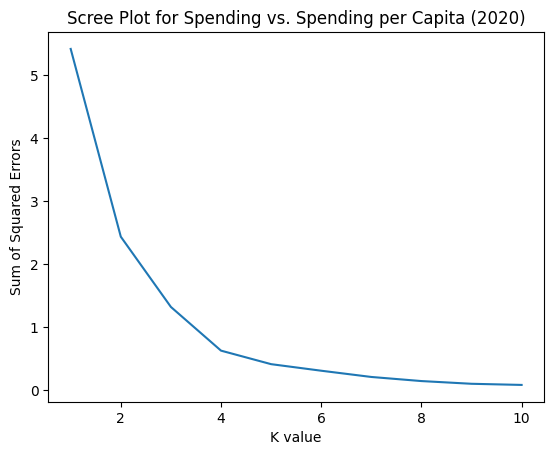


Optimal number of k clusters appears to be 4.


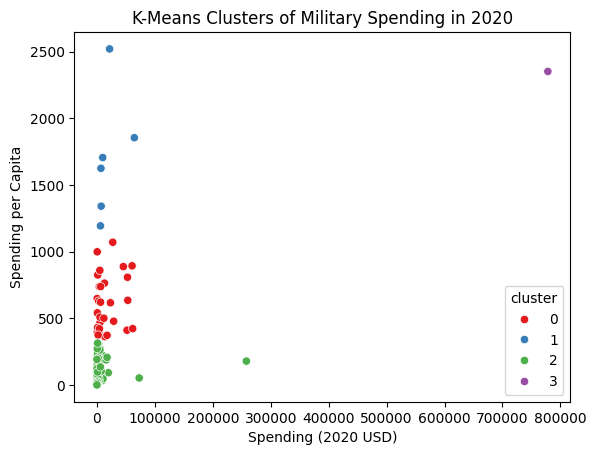

Spending (2020 USD)                                              \
                      count           mean           std            min   
cluster                                                                   
0                      30.0   17077.591354  20583.053357     405.790494   
1                       6.0   19443.362047  22861.507114    6095.708713   
2                     111.0    4859.185065  25405.739131       8.622460   
3                       1.0  778397.200000           NaN  778397.200000   

                                                                     \
                   25%            50%            75%            max   
cluster                                                               
0          2294.039665    5857.060906   26296.001003   61712.537169   
1          7023.251766    8624.225729   18857.070183   64558.400000   
2           130.010211     382.464677    2297.032353  257973.429834   
3        778397.200000  778397.200000  778397.200000  778397.200000   

        Spending per Capita               ... Percent of Government Spending  \
                      count         mean  ...                            75%   
cluster                                   ...                                  
0                      30.0   607.478618  ...                       0.048819   
1                       6.0  1706.721916  ...                       0.164503   
2                     111.0    80.061470  ...                       0.083508   
3                       1.0  2351.631858  ...                       0.081976   

                  Percent of GDP                                          \
              max          count      mean       std       min       25%   
cluster                                                                    
0        0.114776           30.0  0.019397  0.009272  0.006273  0.013892   
1        0.225050            6.0  0.059781  0.031979  0.020060  0.035460   
2        0.303027          111.0  0.017349  0.011699  0.000054  0.010087   
3        0.081976            1.0  0.037179       NaN  0.037179  0.037179   

                                       
              50%       75%       max  
cluster                                
0        0.018834  0.022515  0.042634  
1        0.059257  0.085398  0.098470  
2        0.014389  0.021697  0.066600  
3        0.037179  0.037179  0.037179  

[4 rows x 32 columns]


Observations:
  - Cluster 2 has the highest count with 111 distinct points as well as the lowest mean for total spending--this is most likely the low spending group
  - Cluster 3 only has point and the highest mean total mean spending--graphically, the cluster is a single point and appears to be an outlier compared to the rest of the data
  - Cluster 0 and 1 both have total spending means, but the Per Capita means differ substantially (607 vs. 1,707); this indicates that the K-means seemed to
  have separated them based on their per-capita spending
  - Cluster 3 has an std NaN because it only has one observation
  - General trend: Aside from Group 3, the clusters appear to overlap considerably on the X-axis, or Spending (2020 USD), so the clusters were morso
  informed by the differences in per-capita spending rather than total spending



,index,Spending (2020 USD),Percent of GDP,Percent of Government Spending,Spending per Capita,cluster
count,1.0,1.0,1.000000,1.000000,1.000000,1.0
mean,5540.0,778397.2,0.037179,0.081976,2351.631858,3.0
std,NaN,NaN,NaN,NaN,NaN,NaN
min,5540.0,778397.2,0.037179,0.081976,2351.631858,3.0
25%,5540.0,778397.2,0.037179,0.081976,2351.631858,3.0
50%,5540.0,778397.2,0.037179,0.081976,2351.631858,3.0
75%,5540.0,778397.2,0.037179,0.081976,2351.631858,3.0
max,5540.0,778397.2,0.037179,0.081976,2351.631858,3.0


Based on the given stats, United states is the single observation in Group 3; contextually, this makes sense because we are the leading spenders in defense globally;
thus, K-means isolated it to a single cluster.


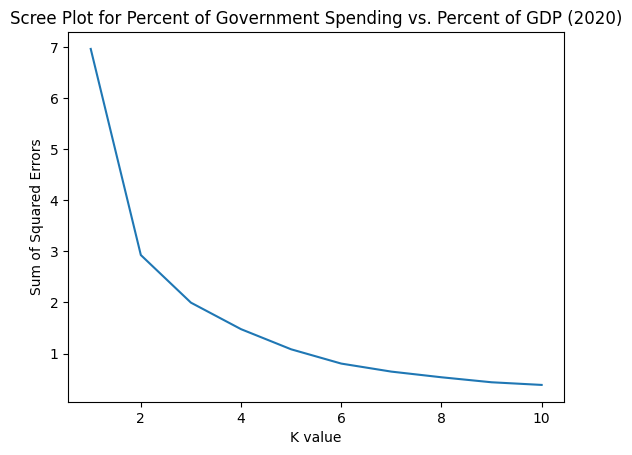


Optimal number of k clusters appears to be 3; harder to distinguish for these features.


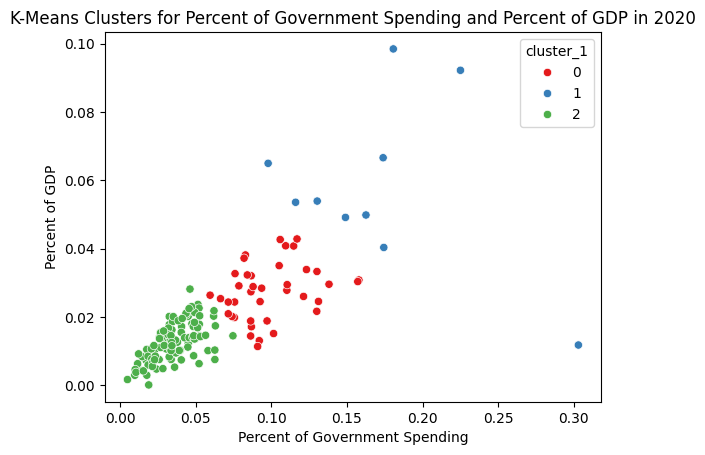

Spending (2020 USD)                                           \
                        count          mean            std         min   
cluster_1                                                                
0                        39.0  27387.150069  124489.244263   44.348098   
1                        10.0  12514.955945   19365.712246  633.960400   
2                        99.0   7611.174172   27958.296403    8.622460   

                                                                  \
                   25%          50%           75%            max   
cluster_1                                                          
0           310.624359  1157.372367   5786.787259  778397.200000   
1          2101.377796  6518.375529  10222.946276   64558.400000   
2           121.641398   567.650747   3910.107493  257973.429834   

          Spending per Capita              ... Percent of Government Spending  \
                        count        mean  ...                            75%   
cluster_1                                  ...                                  
0                        39.0  271.264618  ...                       0.112633   
1                        10.0  817.301890  ...                       0.179081   
2                        99.0  211.624304  ...                       0.047402   

                    Percent of GDP                                          \
                max          count      mean       std       min       25%   
cluster_1                                                                    
0          0.157918           39.0  0.027412  0.008191  0.011317  0.021254   
1          0.303027           10.0  0.058071  0.024867  0.011742  0.049297   
2          0.074624           99.0  0.012664  0.005681  0.000054  0.008393   

                                         
                50%       75%       max  
cluster_1                                
0          0.027781  0.032461  0.042810  
1          0.053729  0.066190  0.098470  
2          0.013191  0.016752  0.028132  

[3 rows x 32 columns]


Observations:
  - The graph suggests that cluster membership was influenced by both features rather than being driven primarily by one.
This is shown by how the clusters separate along both the x and y-axes, showing that both Percent of Government Spending 
and Percent of GDP influence cluster membership
  - There are fewer extreme observations than in the previous K-means clustering; this makes sense because the previous comparison
  in the scatter dealt with magnitudes of dollars, whereas this comparison utilized percentages
  - The highest count cluster--Cluster 2--still has the lowest Spending and Spending per Capita
  - General Trend: Focused on low->moderate->high spending-share pattern across the two features



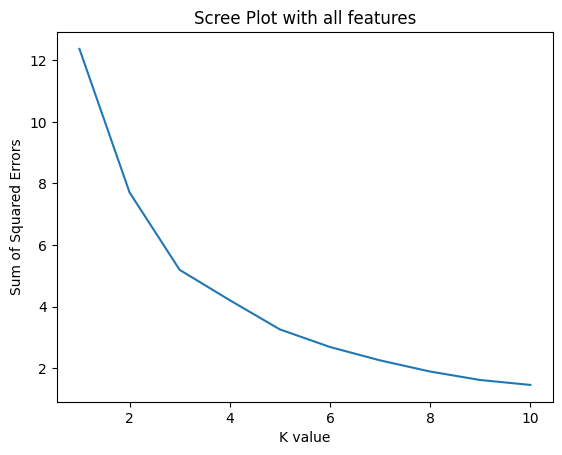


Optimal number of k clusters appears to be 5.


Spending (2020 USD)                                              \
                          count           mean           std            min   
cluster_all                                                                   
0                          86.0    4513.543790  27841.230783       8.622460   
1                           1.0  778397.200000           NaN  778397.200000   
2                          30.0    9073.543709  18135.032885     163.926877   
3                          26.0   15330.618681  18923.469359     405.790494   
4                           5.0   21878.058451  24674.937388    6095.708713   

                                                                         \
                       25%            50%            75%            max   
cluster_all                                                               
0                81.022976     288.061512    1138.618231  257973.429834   
1            778397.200000  778397.200000  778397.200000  778397.200000   
2               522.737081    1663.090134    8646.648849   72937.064048   
3              3176.345598    5857.060906   21818.934764   60675.039625   
4              6941.042345    9978.571429   21816.569767   64558.400000   

            Spending per Capita               ...  \
                          count         mean  ...   
cluster_all                                   ...   
0                          86.0    70.290644  ...   
1                           1.0  2351.631858  ...   
2                          30.0   215.920971  ...   
3                          26.0   612.677541  ...   
4                           5.0  1779.854530  ...   

            Percent of Government Spending           Percent of GDP            \
                                       75%       max          count      mean   
cluster_all                                                                     
0                                 0.053006  0.101501           86.0  0.012481   
1                                 0.081976  0.081976            1.0  0.037179   
2                                 0.136403  0.303027           30.0  0.034105   
3                                 0.044645  0.052209           26.0  0.016585   
4                                 0.180654  0.225050            5.0  0.067725   

                                                                         
                  std       min       25%       50%       75%       max  
cluster_all                                                              
0            0.005799  0.000054  0.007811  0.012532  0.016783  0.026340  
1                 NaN  0.037179  0.037179  0.037179  0.037179  0.037179  
2            0.011116  0.011742  0.027933  0.032148  0.040637  0.066600  
3            0.005525  0.006273  0.013689  0.015324  0.020431  0.028132  
4            0.028372  0.029429  0.053553  0.064961  0.092211  0.098470  

[5 rows x 32 columns]


Observations:
- Cluster 0 is the largest, with 86 countries, indicating that most countries fall into
  one broad four-variable spending profile.
- Cluster 1 contains only the United States, which remains isolated because of its extremely
  high total military spending.
- The four-variable model retains the extreme-spending pattern seen in Part 2 whilst
  incorporating the spending-share differences identified in Part 3.
- Compared with the two-variable models, the four-variable model produces more differentiated
  groups because cluster membership now depends simultaneously on absolute spending,
  per-capita spending, government-spending share, and GDP share.
- Cluster sizes remain uneven (86, 1, 30, 26, and 5), with one dominant group and several
  smaller groups representing less common spending profiles.


The k-MC algorithm showcased a few useful patterns. Most distinctly, large-cluster countries
trended towards relatively low military spending, while smaller clusters captured co

In [5]:
# Q2.1
df = pd.read_csv("A04-clustering/data/SIPRI Military Expenditure Database.csv")

# Make df calls just for when Year = 2020
df = df[df["Year"]==2020]

#Drop all null values
df_filtered = df.dropna()

# Verify all null values are dropped
print(f'Number of NaN values: {df_filtered.isna().sum()}')
display(df_filtered.describe())
display(df_filtered.head())

# --ADDITIONAL CLEANING (prior to min-max scaling)--

# Check for suspicious amounts of zeroes
zero_percentages = (df == 0).mean() * 100
print(f'Percentage of zeros: {zero_percentages}')

# Duplicate check
print(f'Number of duplicates: {df.duplicated().sum()}')

# Remove Year Column (Everything already filtered to Year 2020)
df_filtered = df_filtered.drop(columns=["Year"])
display(df_filtered.describe())

# Q2.2

# Scale the two features
features = ["Spending (2020 USD)","Spending per Capita"]
unscaled = df_filtered.loc[:, features]
mins = unscaled.min()
ranges = unscaled.max() - mins
X_spending = (unscaled - mins) / ranges
X_spending.agg(["min", "max"])


# Create Scree plot for Spending (2020 USD) and Spending per Capita
ks = np.arange(1,11)
SSE = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_spending).inertia_
    for k in ks
]

plt.figure()
sns.lineplot(x=ks, y=SSE)
plt.xlabel("K value")
plt.ylabel("Sum of Squared Errors")
plt.title("Scree Plot for Spending vs. Spending per Capita (2020)")
plt.show()

print("""
Optimal number of k clusters appears to be 4.""")

# Create Scatter plot with hues

# Re-run with k = 4
model = KMeans(
    n_clusters=4,
    max_iter=300,
    n_init=10,
    random_state=0
).fit(X_spending)

# Make cluster labels a column
df_filtered['cluster']=model.labels_

# Create scatter

sns.scatterplot(
    data=df_filtered,
    x="Spending (2020 USD)",
    y="Spending per Capita",
    hue="cluster",
    palette="Set1"
)

plt.title("K-Means Clusters of Military Spending in 2020")
plt.show()

# Describe Table
display(df_filtered.groupby("cluster")[
    [
        "Spending (2020 USD)",
        "Spending per Capita",
        "Percent of Government Spending",
        "Percent of GDP"
    ]
].describe())

print("""
Observations:
  - Cluster 2 has the highest count with 111 distinct points as well as the lowest mean for total spending--this is most likely the low spending group
  - Cluster 3 only has point and the highest mean total mean spending--graphically, the cluster is a single point and appears to be an outlier compared to the rest of the data
  - Cluster 0 and 1 both have total spending means, but the Per Capita means differ substantially (607 vs. 1,707); this indicates that the K-means seemed to
  have separated them based on their per-capita spending
  - Cluster 3 has an std NaN because it only has one observation
  - General trend: Aside from Group 3, the clusters appear to overlap considerably on the X-axis, or Spending (2020 USD), so the clusters were morso
  informed by the differences in per-capita spending rather than total spending
""")

# Find stats on the United States:
display(df_filtered[df_filtered['Country']=='United States of America'].describe())

print("""Based on the given stats, United states is the single observation in Group 3; contextually, this makes sense because we are the leading spenders in defense globally;
thus, K-means isolated it to a single cluster.""")

# Q2.3

# Scale the two features
features_1 = ["Percent of Government Spending","Percent of GDP"]
unscaled_1 = df_filtered.loc[:, features_1]
mins_1 = unscaled_1.min()
ranges_1 = unscaled_1.max() - mins_1
X_government_spending = (unscaled_1 - mins_1) / ranges_1
X_government_spending.agg(["min", "max"])


# Create Scree plot for Spending (2020 USD) and Spending per Capita
ks = np.arange(1,11)
SSE = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_government_spending).inertia_
    for k in ks
]

plt.figure()
sns.lineplot(x=ks, y=SSE)
plt.xlabel("K value")
plt.ylabel("Sum of Squared Errors")
plt.title("Scree Plot for Percent of Government Spending vs. Percent of GDP (2020)")
plt.show()

print("""
Optimal number of k clusters appears to be 3; harder to distinguish for these features.""")

# Create Scatter plot with hues

# Re-run with k = 3
model = KMeans(
    n_clusters=3,
    max_iter=300,
    n_init=10,
    random_state=0
).fit(X_government_spending)

# Make cluster labels a column
df_filtered['cluster_1']=model.labels_

# Create scatter plot
sns.scatterplot(
    data=df_filtered,
    x="Percent of Government Spending",
    y="Percent of GDP",
    hue="cluster_1",
    palette="Set1"
)

plt.title("K-Means Clusters for Percent of Government Spending and Percent of GDP in 2020")
plt.show()

# Describe Table
display(df_filtered.groupby("cluster_1")[
    [
        "Spending (2020 USD)",
        "Spending per Capita",
        "Percent of Government Spending",
        "Percent of GDP"
    ]
].describe())


print("""
Observations:
  - The graph suggests that cluster membership was influenced by both features rather than being driven primarily by one.
This is shown by how the clusters separate along both the x and y-axes, showing that both Percent of Government Spending
and Percent of GDP influence cluster membership
  - There are fewer extreme observations than in the previous K-means clustering; this makes sense because the previous comparison
  in the scatter dealt with magnitudes of dollars, whereas this comparison utilized percentages
  - The highest count cluster--Cluster 2--still has the lowest Spending and Spending per Capita
  - General Trend: Focused on low->moderate->high spending-share pattern across the two features
""")

# Q2.4
features_all = [
    'Spending (2020 USD)',
    'Spending per Capita',
    'Percent of Government Spending',
    'Percent of GDP'
]

unscaled_all = df_filtered[features_all]

mins = unscaled_all.min()
ranges = unscaled_all.max() - mins

X_all = (unscaled_all - mins) / ranges

# Scree Plot for all features
ks = np.arange(1,11)
SSE = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_all).inertia_
    for k in ks
]

plt.figure()
sns.lineplot(x=ks, y=SSE)
plt.xlabel("K value")
plt.ylabel("Sum of Squared Errors")
plt.title("Scree Plot with all features")
plt.show()

print("""
Optimal number of k clusters appears to be 5.""")

# Create Scatter plot with hues

# Re-run with k = 5
model = KMeans(
    n_clusters=5,
    max_iter=300,
    n_init=10,
    random_state=0
).fit(X_all)

# Make cluster labels a column
df_filtered['cluster_all']=model.labels_

# Describe Table
display(df_filtered.groupby("cluster_all")[
    [
        "Spending (2020 USD)",
        "Spending per Capita",
        "Percent of Government Spending",
        "Percent of GDP"
    ]
].describe())

print("""
Observations:
- Cluster 0 is the largest, with 86 countries, indicating that most countries fall into
  one broad four-variable spending profile.
- Cluster 1 contains only the United States, which remains isolated because of its extremely
  high total military spending.
- The four-variable model retains the extreme-spending pattern seen in Part 2 whilst
  incorporating the spending-share differences identified in Part 3.
- Compared with the two-variable models, the four-variable model produces more differentiated
  groups because cluster membership now depends simultaneously on absolute spending,
  per-capita spending, government-spending share, and GDP share.
- Cluster sizes remain uneven (86, 1, 30, 26, and 5), with one dominant group and several
  smaller groups representing less common spending profiles.
""")

# Q2.5

print("""
The k-MC algorithm showcased a few useful patterns. Most distinctly, large-cluster countries
trended towards relatively low military spending, while smaller clusters captured countries with higher spending
per capita or higher military spending as a share of GDP and government spending. The analysis also identified an extreme
high-spending country--the United States--that separated from the rest of the data. In totality, the clustering showed that countries
differ not only in how much they spend, but also in how large that spending is relative to their population and economy.""")


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 915e681b0a235a2a1a3208865b20a5bafa94c09b
- **AI tool and model used:** GPT 6 High

### *Prompts used

1. "Please review my existing Phase 1 code and responses alongside the original assignment instructions and suggest improvements for Phase 2. Check for basic errors (typos, logic, formatting, calculations, etc.), and make sure I've fully and accurately answered every question, including any requirements for visuals, computations, written explanations, and interpretations of results. Also look for ways to improve code efficiency, readability, and overall quality, as well as alternative approaches I may not have considered in my original solution. Please number each proposed change (Change 1, Change 2, etc.) and explain what should be changed and why, so I can directly copy and paste your suggestions into my Phase 2 documentation. Distinguish between necessary fixes and optional improvements, and focus on specific changes rather than rewriting my entire solution."
2. Please incorporate the changes following changes except for the following: Change 5 (do not proceed with the duplicate suggestion; only do the portion about turning the total sum of missing values into a single number), Change 11, Change 14, change 15. When incoporating the changes, keep the structure of the original phase 1 code, with as minimal changes as possible--they should only be augmentations of what was previously established (with your suggestions in mind.)
3. I like the implemented revisions; however, I believe you fundamentally changed some of my written responses; please limit to improving accuracy + precision of my responses, adding any necessary clarification, and do not incorporate new ideas for interpretation unless they are pertinent additions that were missed during initial analysis.

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

**Change 1 — Necessary | Q1.2: Color scatterplots by group**

Modify the five scatterplots to distinguish observations by their original group (`a`, `b`, or `c`), using the `group` column as the hue. The current scatterplots display all observations without distinguishing group membership, even though the question specifically requests scatterplots by group. This change will make cluster overlap and the effects of increasing noise easier to observe.

**Change 2 — Necessary | Q1.3: Improve scree plot comparability**

Place all five SSE curves on a single graph or use consistent y-axis limits across the separate plots. Currently, each scree plot automatically adjusts its vertical axis, making it difficult to compare the magnitude of SSE and the strength of the elbow across noise levels. A combined plot will better illustrate how increasing noise affects the clustering results.

**Change 3 — Necessary | Q1.4: Refine the explanation of the elbow method**

Revise the explanation suggesting that the elbow point prevents overfitting and maximizes cluster compactness. Increasing \(k\) generally decreases SSE, so the elbow does not maximize compactness or guarantee better generalization. Instead, explain that the elbow method balances reducing within-cluster variation against introducing additional clusters that provide diminishing improvements in SSE.

**Change 4 — Necessary | Q2.1: Strengthen data-cleaning verification**

Explicitly verify that filtering for 2020 and removing missing observations produces 148 countries. Check for duplicate country names, confirm that the four clustering variables are numeric, and remove the redundant `index` column imported from the CSV. Conclude whether additional cleaning is necessary rather than relying exclusively on displayed descriptive statistics. Removing the `index` column is primarily housekeeping because the existing clustering code already excludes it.

**Change 5 — Necessary | Q2.1: Correct the consistency of cleaning checks**

Run the zero-value and duplicate checks on `df_filtered` rather than `df`, since `df_filtered` is the dataset actually used for clustering. Check duplicate countries using the `Country` column rather than only checking for identical full rows. Additionally, report the total number of missing values as a single number rather than a Series to make the verification output easier to interpret.

**Change 6 — Necessary | Q2.2–Q2.4: Better justify the selected number of clusters**

Provide a more explicit explanation for selecting \(k=4\), \(k=3\), and \(k=5\) in the three clustering analyses. Identify where the reduction in SSE begins to diminish for each model and acknowledge any ambiguity in the elbow. This will strengthen the connection between the scree plots and the selected cluster counts instead of relying primarily on visual estimates.

**Change 7 — Necessary | Q2.2: Improve verification of cluster membership**

Explicitly display the United States' cluster assignment alongside its country name and spending variables rather than using `.describe()` on its single observation. Also verify cluster sizes and single-country clusters using the actual fitted labels. This makes the country-level conclusions more transparent and avoids relying on manually transcribed cluster statistics.

**Change 8 — Necessary | Q2.2–Q2.3: Clarify interpretations of cluster separation**

Revise explanations attributing cluster separation to particular variables without sufficient numerical support. Because K-means operates on min-max normalized values, the relative importance of features should be assessed using the normalized cluster centers alongside the original-scale summary statistics. Also clarify that differences in extreme observations between the dollar-based and percentage-based models are not automatically explained by their measurement units.

**Change 9 — Necessary | Q2.3: Strengthen the comparison with Q2.2**

Expand the comparison between the two-variable models by discussing differences in cluster sizes, spending profiles, and the United States' cluster membership. Distinguish the variables used to form clusters from variables included only for descriptive purposes. This will make the comparison more specific and help explain what each feature combination reveals about military spending.

**Change 10 — Necessary | Q2.4: Support the four-variable model comparison**

Support the comparison of the four-variable model with the previous models using actual cluster means, sizes, and representative countries. Revise the statement that the four-variable model produces "more differentiated" clusters simply because it uses additional variables or identifies five clusters. A larger number of clusters does not necessarily indicate a better solution. Instead, describe the additional spending patterns revealed by including all four features.

**Change 11 — Optional | Q2.4: Add a visualization of the four-variable clustering**

Consider adding a PCA scatterplot displaying the four-variable model's cluster assignments in two dimensions. Unlike the previous two-variable analyses, the four-variable model does not currently have a scatterplot, although Q2.4 does not explicitly require one. PCA would provide an additional visual comparison of cluster separation while preserving the original four-variable K-means model.

**Change 12 — Optional | Q2.2–Q2.4: Add cluster-center summary tables**

Supplement the existing `.groupby().describe()` outputs with smaller tables showing cluster counts and mean values for the relevant features. These tables would improve readability and allow easier comparison of cluster characteristics without navigating large descriptive-statistics outputs.

**Change 13 — Optional | Q1–Q2: Reduce repetitive code**

Create reusable functions for producing scree plots, applying min-max normalization, and fitting K-means models. The current solution repeats nearly identical code for multiple datasets and feature combinations. Consolidating these operations would improve efficiency, readability, and consistency while preserving the original methodology.

**Change 14 — Optional | Q2.2–Q2.4: Evaluate alternative cluster-selection methods**

Consider supplementing the elbow method with silhouette scores to evaluate the degree of separation between clusters. This could provide additional evidence for the selected values of \(k\), particularly where the elbows are ambiguous. The elbow method should remain the primary approach because it is explicitly requested in the assignment.

**Change 15 — Optional | Q2.2–Q2.5: Examine sensitivity to outliers**

Investigate how extreme-spending countries, particularly the United States, influence cluster membership and the results of min-max normalization. A sensitivity analysis could compare the original clustering with results obtained after excluding the United States or applying a logarithmic transformation to the dollar-based variables. Retain the original min-max models for the required analysis, using these alternative approaches only to assess robustness.

**Change 16 — Optional | Q1–Q2: Improve formatting and portability**

Correct minor wording and formatting errors, including "eblow" to "elbow," "derease" to "decrease," "morso" to "more so," and "Cluster 3 only has point" to "Cluster 3 contains only one observation." Remove the unused `StandardScaler` import. If the exported `.py` file is intended to run outside Colab, replace the notebook-only `!git clone` command with a Python-compatible alternative and document the required CSV path.

**Change 17 — Optional | Q2.5: Discuss limitations of the conclusions**

Expand the final discussion to acknowledge that K-means identifies descriptive patterns rather than causal relationships. Mention that cluster assignments depend on feature selection, scaling, and the selected number of clusters. This would provide a more balanced assessment of the algorithm's usefulness for analyzing military spending.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | **Accept** / modify / reject | The original question does emphasize that group membership should be separated; after implementation, the hue clearly depicts the size and shape of each cluster and avoids homogenizing the observations |
| 2 | **Accept** / modify / reject | Separated scree plots make comparison a little more difficult, so a combined and color-coded version is optimal; verification done via visual check--new visual retains the same figures but with enhanced clarity and comparability of elbows|
| 3 | **Accept** / modify / reject | My original sentiment, while headed in the right direction, was too strong of an assertion; the AI-provided explanation is more objective about the purpose of the elbow method, which is 1) reducing diminishing returns in SSE whilst 2) keeping the compactness of the within-cluster variation. Information verified by Clustering slides for class |
| 4 | **Accept** / modify / reject | Simple formatting improvements and additional sentence that explicitly states what cleaning is necessary |
| 5 | Accept / **modify** / reject | I don't believe the duplicate suggestion is necessary; however, changing the number of missing values from a series to a single number enhances clarity significantly. |
| 6 | **Accept** / modify / reject | Simple clarification improvement regarding selection of elbow; original explanation already met requirements, but AI suggestion provides a more empirical description (i.e. where exactly SSE reductions begin to diminish) to justify elbow selection |
| 7 | **Accept** / modify / reject | Strong formatting augmentation that doesn't change the code logic but provides a clearer visual that strengthens written observation |
| 8 | Accept / **modify** / reject | For the purposes of this assignment, I don't believe a direct comparison for the normalized and original summary is necessary; however, I will include some additional clarification regarding the differences in extreme observations since that is one of the more striking differences from the two K-means outputs |
| 9 | **Accept** / modify / reject | Good suggestion that attempts to strengthen the comparison by highlighting more differences between the two graphics; the generated cross-tabulations and additional written differences definitely improved breadth of analysis |
| 10 | **Accept** / modify / reject | While I didn't necessarily mean for "more differentiated" to imply better, I can see where the confusion can occur; the additional AI-generated visuals also provided cleaner representations of the data (i.e. mean, standard deviation, labels themselves, etc...)|
| 11 | Accept / modify / **reject** | Not necessary for this analysis |
| 12 | **Accept** / modify / reject | Cluster summary tables are especially useful because my original visuals were often chopped off and may have left some important information out of sight; the new tables are smaller but contain the necessary information |
| 13 | **Accept** / modify / reject | Simple code efficiency improvement; makes code cleaner and more reproducible |
| 14 | Accept / modify / **reject** | While a good extension, not necessary for the purposes (and would be time-intensive) for this assignment |
| 15 | Accept / modify / **reject** | Good extension, but out of scope for this assignment |
| 16 | **Accept** / modify / reject | Good redundancy, spelling, and formatting check; new implementation is, by and large, cleaner and less riddled with spelling mistakes |
| 17 | **Accept** / modify / reject | I am always keen on making my discussions more descriptive and neutral rather than causal for data analysis; for this particular assignment, it is especially important to maintain that K-means patterns and clustering signify descriptive patterns rather than causal relationships |


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

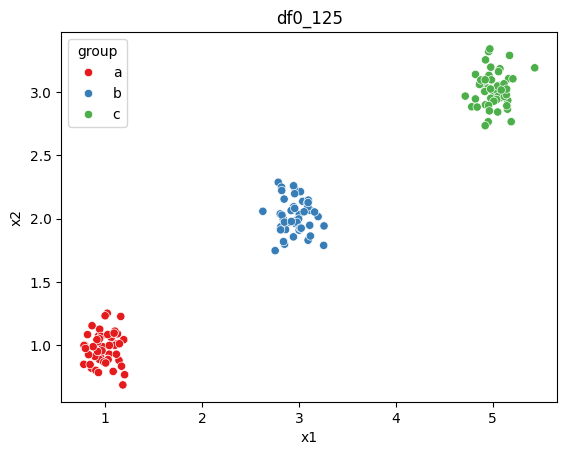

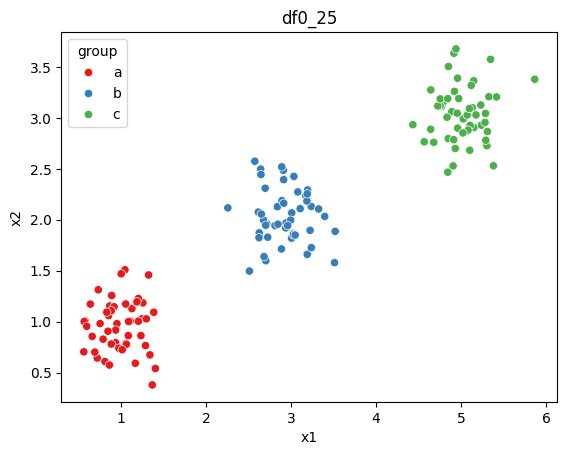

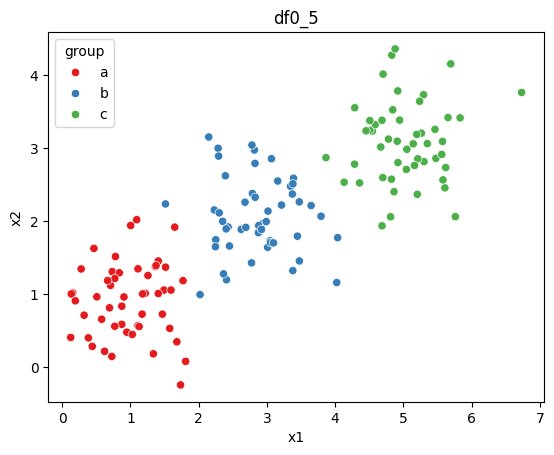

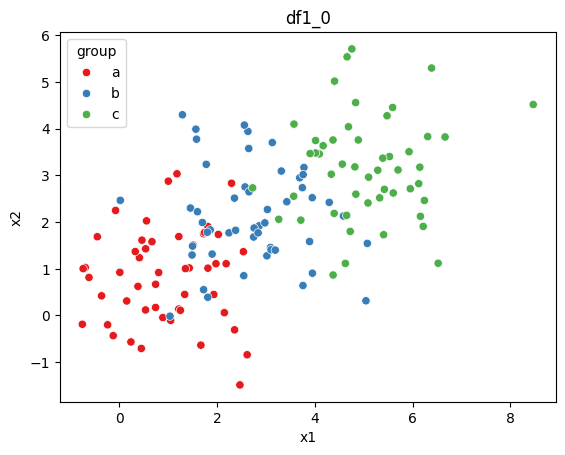

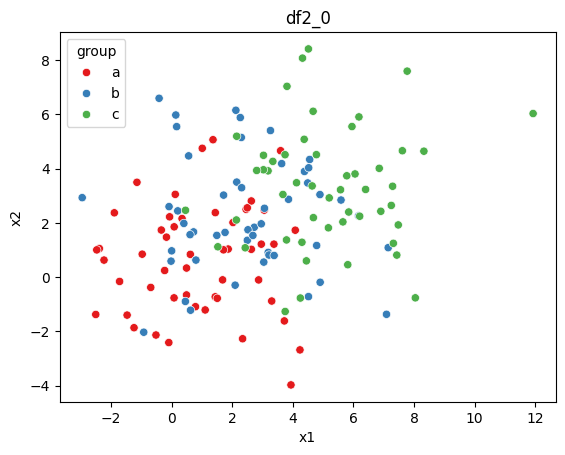


Looking at the scatterplots, the visual distinctness of the clusters diminishes
as the amount of noise in the dataset increases from 0.125 to 2.0. In other words,
the points become more dispersed rather than concentrated, making each individual cluster
harder to distinguish from the others. The different group colors also show how the original
groups begin overlapping more as noise increases.



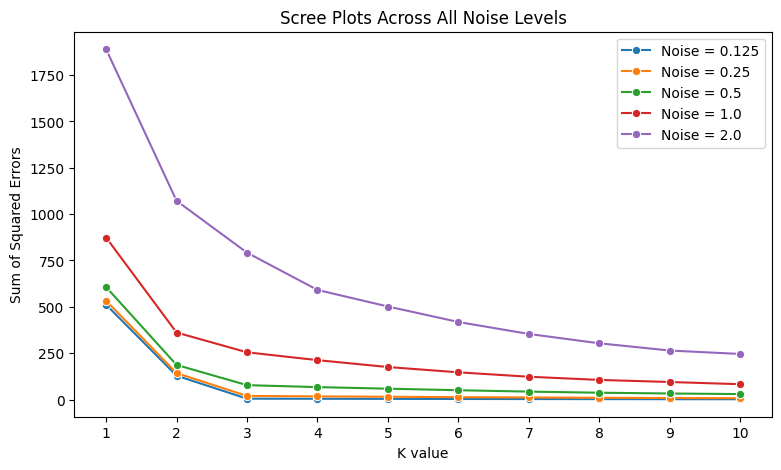


As seen from the scree plots, higher levels of noise make an elbow point less discernible,
with each line plot becoming smoother around the drop-off zone (i.e., the point(s) on the line
at which the SSE decreases sharply) from 0.125 to 2.0 noise. For example, at Noise Level 0.125,
the elbow is almost certainly located at k = 3. Conversely, the elbow point for Noise Level 2.0
could be any k-value between 3 and 5--this is because there is not as sharp of a bend
in the SSE curve, making it harder to select which would be the most appropriate candidate.
The combined scree plot also makes the higher SSE values at greater noise levels easier to compare.


The elbow point signals a k-value when decreases in error, more specifically SSE, for a given set of k-values
slow down substantially. For example, in the numerical simulations above, plausible elbow points would be the following
k-values:
  - 0.125: 3
  - 0.25: 3
  - 0.5: 3
  - 1.0: 3 or 4
  - 2.0: 3, 4 or 5
Matching these values to the g

,index,Year,Spending (2020 USD),Percent of GDP,Percent of Government Spending,Spending per Capita
count,148.000000,148.0,148.000000,148.000000,148.000000,148.000000
mean,2831.256757,2020.0,13153.747670,0.019619,0.061510,268.264494
std,1654.299355,0.0,68005.236120,0.015033,0.046207,430.434878
min,32.000000,2020.0,8.622460,0.000054,0.004896,0.580129
25%,1409.000000,2020.0,204.877177,0.010413,0.031352,20.553464
50%,2871.000000,2020.0,959.535443,0.015324,0.047402,81.506703
75%,4222.500000,2020.0,5289.998320,0.024327,0.084681,326.267753
max,5880.000000,2020.0,778397.200000,0.098470,0.303027,2520.398541


,index,Year,Country,Spending (2020 USD),Percent of GDP,Percent of Government Spending,Spending per Capita
32,32,2020,Afghanistan,279.576955,0.013589,0.049728,7.181899
66,66,2020,Albania,187.433234,0.012583,0.037952,65.126211
100,100,2020,Algeria,9708.277440,0.066600,0.173924,221.392384
134,134,2020,Angola,993.594405,0.014442,0.074624,30.231680
168,168,2020,Argentina,2830.929705,0.007269,0.017268,62.636731


Percentage of zeros: index                             0.0
Year                              0.0
Country                           0.0
Spending (2020 USD)               0.0
Percent of GDP                    0.0
Percent of Government Spending    0.0
Spending per Capita               0.0
dtype: float64
Number of duplicates: 0


,Spending (2020 USD),Percent of GDP,Percent of Government Spending,Spending per Capita
count,148.000000,148.000000,148.000000,148.000000
mean,13153.747670,0.019619,0.061510,268.264494
std,68005.236120,0.015033,0.046207,430.434878
min,8.622460,0.000054,0.004896,0.580129
25%,204.877177,0.010413,0.031352,20.553464
50%,959.535443,0.015324,0.047402,81.506703
75%,5289.998320,0.024327,0.084681,326.267753
max,778397.200000,0.098470,0.303027,2520.398541


All four clustering variables numeric: True
Cleaning conclusion: After filtering to 2020 and dropping missing rows, the four numeric variables can be used for min-max scaling without additional transformations. The Year and redundant index columns were removed because they are not clustering features.


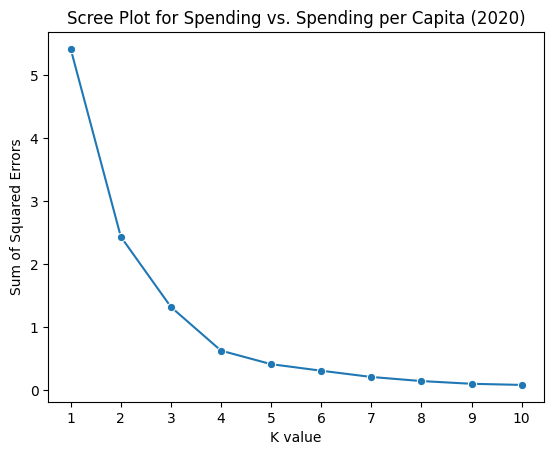


Optimal number of k clusters appears to be 4. The SSE decreases most rapidly for
smaller k-values and begins to level out near k = 4. The elbow is a visual
judgment rather than proof that four clusters is uniquely optimal.

SSE reduction from k=3 to 4: 0.692; from k=4 to 5: 0.214


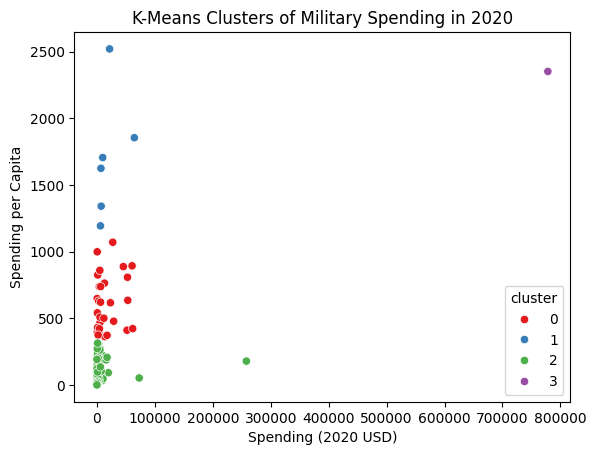

Spending (2020 USD)                                              \
                      count           mean           std            min   
cluster                                                                   
0                      30.0   17077.591354  20583.053357     405.790494   
1                       6.0   19443.362047  22861.507114    6095.708713   
2                     111.0    4859.185065  25405.739131       8.622460   
3                       1.0  778397.200000           NaN  778397.200000   

                                                                     \
                   25%            50%            75%            max   
cluster                                                               
0          2294.039665    5857.060906   26296.001003   61712.537169   
1          7023.251766    8624.225729   18857.070183   64558.400000   
2           130.010211     382.464677    2297.032353  257973.429834   
3        778397.200000  778397.200000  778397.200000  778397.200000   

        Spending per Capita               ... Percent of Government Spending  \
                      count         mean  ...                            75%   
cluster                                   ...                                  
0                      30.0   607.478618  ...                       0.048819   
1                       6.0  1706.721916  ...                       0.164503   
2                     111.0    80.061470  ...                       0.083508   
3                       1.0  2351.631858  ...                       0.081976   

                  Percent of GDP                                          \
              max          count      mean       std       min       25%   
cluster                                                                    
0        0.114776           30.0  0.019397  0.009272  0.006273  0.013892   
1        0.225050            6.0  0.059781  0.031979  0.020060  0.035460   
2        0.303027          111.0  0.017349  0.011699  0.000054  0.010087   
3        0.081976            1.0  0.037179       NaN  0.037179  0.037179   

                                       
              50%       75%       max  
cluster                                
0        0.018834  0.022515  0.042634  
1        0.059257  0.085398  0.098470  
2        0.014389  0.021697  0.066600  
3        0.037179  0.037179  0.037179  

[4 rows x 32 columns]

,Country count,Spending (2020 USD),Spending per Capita
cluster,,,
0,30,17077.591,607.479
1,6,19443.362,1706.722
2,111,4859.185,80.061
3,1,778397.200,2351.632


Cluster centers (min-max normalized):


,Spending (2020 USD),Spending per Capita
cluster,,
0,0.022,0.241
1,0.025,0.677
2,0.006,0.032
3,1.000,0.933



Observations:
  - Cluster 2 has the highest count with 111 distinct points as well as the lowest mean for total spending--this is most likely the low-spending group.
  - Cluster 3 has 1 point(s) and the highest mean total
    spending--graphically, the cluster is a single point and appears to be an outlier compared to the rest of the data.
  - Clusters 0 and 1 have different total spending means, but the per-capita means differ substantially
    (607 vs. 1,707); this indicates that K-means seemed
    to have separated them partly based on their per-capita spending.
  - A cluster with only one observation has an std of NaN because sample standard deviation is undefined for one point.
  - General trend: Aside from the highest-total-spending group, the clusters appear to overlap considerably on the X-axis,
    or Spending (2020 USD), so the clusters were more strongly informed by differences in per-capita spending rather than
    total spending among those overlapping groups. The normali

,Country,cluster,Spending (2020 USD),Spending per Capita
5540,United States of America,3,778397.2,2351.631858


Based on the given stats, the United States is the single observation in Group 3;
contextually, this makes sense because the United States has exceptionally high total defense spending;
thus, K-means isolated it into a single cluster.


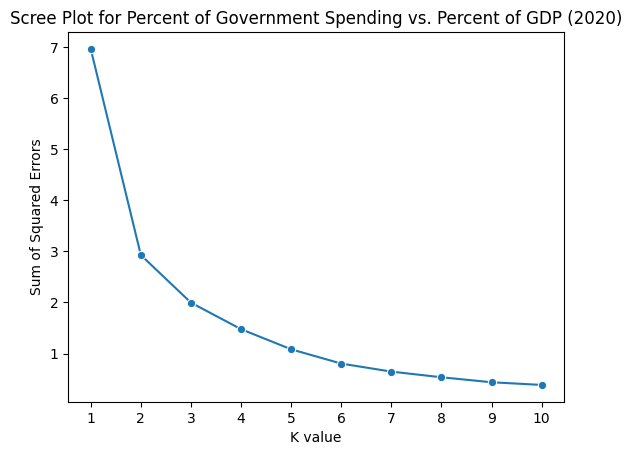


Optimal number of k clusters appears to be 3; harder to distinguish for these
features. I selected k = 3 based on the apparent slowdown in SSE reduction,
although the elbow is less definitive than in the previous analysis.

SSE reduction from k=2 to 3: 0.932; from k=3 to 4: 0.519


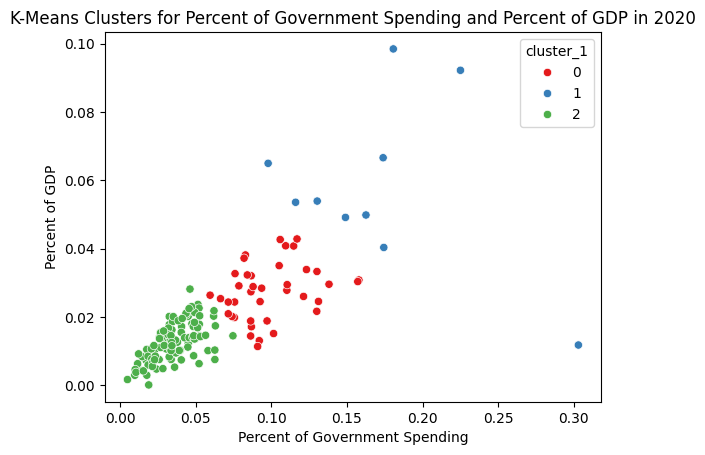

Spending (2020 USD)                                           \
                        count          mean            std         min   
cluster_1                                                                
0                        39.0  27387.150069  124489.244263   44.348098   
1                        10.0  12514.955945   19365.712246  633.960400   
2                        99.0   7611.174172   27958.296403    8.622460   

                                                                  \
                   25%          50%           75%            max   
cluster_1                                                          
0           310.624359  1157.372367   5786.787259  778397.200000   
1          2101.377796  6518.375529  10222.946276   64558.400000   
2           121.641398   567.650747   3910.107493  257973.429834   

          Spending per Capita              ... Percent of Government Spending  \
                        count        mean  ...                            75%   
cluster_1                                  ...                                  
0                        39.0  271.264618  ...                       0.112633   
1                        10.0  817.301890  ...                       0.179081   
2                        99.0  211.624304  ...                       0.047402   

                    Percent of GDP                                          \
                max          count      mean       std       min       25%   
cluster_1                                                                    
0          0.157918           39.0  0.027412  0.008191  0.011317  0.021254   
1          0.303027           10.0  0.058071  0.024867  0.011742  0.049297   
2          0.074624           99.0  0.012664  0.005681  0.000054  0.008393   

                                         
                50%       75%       max  
cluster_1                                
0          0.027781  0.032461  0.042810  
1          0.053729  0.066190  0.098470  
2          0.013191  0.016752  0.028132  

[3 rows x 32 columns]

,Country count,Percent of Government Spending,Percent of GDP
cluster_1,,,
0,39,0.099,0.027
1,10,0.171,0.058
2,99,0.036,0.013


Cluster centers (min-max normalized):


,Percent of Government Spending,Percent of GDP
cluster_1,,
0,0.315,0.278
1,0.558,0.590
2,0.104,0.128


Comparison of country membership between Q2.2 and Q2.3:


cluster_1,0,1,2
cluster,,,
0,5,0,25
1,1,4,1
2,32,6,73
3,1,0,0


United States membership in the two analyses:


,Country,cluster,cluster_1,Percent of Government Spending,Percent of GDP
5540,United States of America,3,0,0.081976,0.037179



Observations:
  - The graph suggests that cluster membership was influenced by both features rather than being driven primarily by one.
    This is shown by how the clusters separate along both the x and y-axes, showing that both Percent of Government Spending
    and Percent of GDP influence cluster membership. The normalized cluster centers help support this interpretation.
  - There appear to be fewer extreme observations than in the previous K-means clustering. The previous comparison
    in the scatter dealt with magnitudes of dollars, whereas this comparison utilized percentages; more precisely,
    the two analyses emphasize different aspects of spending, so their scatterplots are not directly comparable in scale.
  - The highest-count cluster--Cluster 2--still has the lowest Spending and Spending per Capita.
  - General Trend: Focused on a low -> moderate -> high spending-share pattern across the two features.
  - Compared with Part 2, cluster membership now reflects how large

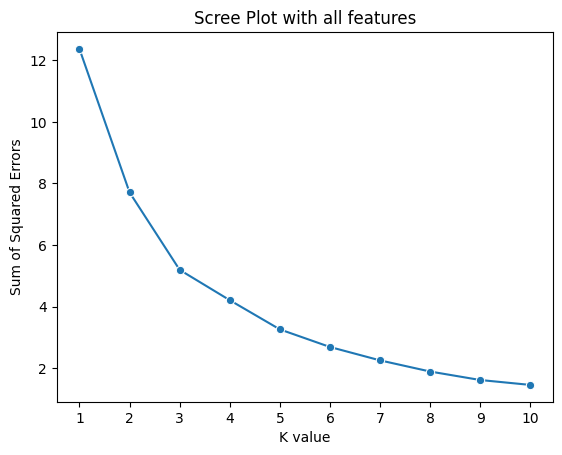


Optimal number of k clusters appears to be 5. The SSE curve begins to flatten
around this value, though the choice is still based on an approximate elbow.

SSE reduction from k=4 to 5: 0.949; from k=5 to 6: 0.572


Spending (2020 USD)                                              \
                          count           mean           std            min   
cluster_all                                                                   
0                          86.0    4513.543790  27841.230783       8.622460   
1                           1.0  778397.200000           NaN  778397.200000   
2                          30.0    9073.543709  18135.032885     163.926877   
3                          26.0   15330.618681  18923.469359     405.790494   
4                           5.0   21878.058451  24674.937388    6095.708713   

                                                                         \
                       25%            50%            75%            max   
cluster_all                                                               
0                81.022976     288.061512    1138.618231  257973.429834   
1            778397.200000  778397.200000  778397.200000  778397.200000   
2               522.737081    1663.090134    8646.648849   72937.064048   
3              3176.345598    5857.060906   21818.934764   60675.039625   
4              6941.042345    9978.571429   21816.569767   64558.400000   

            Spending per Capita               ...  \
                          count         mean  ...   
cluster_all                                   ...   
0                          86.0    70.290644  ...   
1                           1.0  2351.631858  ...   
2                          30.0   215.920971  ...   
3                          26.0   612.677541  ...   
4                           5.0  1779.854530  ...   

            Percent of Government Spending           Percent of GDP            \
                                       75%       max          count      mean   
cluster_all                                                                     
0                                 0.053006  0.101501           86.0  0.012481   
1                                 0.081976  0.081976            1.0  0.037179   
2                                 0.136403  0.303027           30.0  0.034105   
3                                 0.044645  0.052209           26.0  0.016585   
4                                 0.180654  0.225050            5.0  0.067725   

                                                                         
                  std       min       25%       50%       75%       max  
cluster_all                                                              
0            0.005799  0.000054  0.007811  0.012532  0.016783  0.026340  
1                 NaN  0.037179  0.037179  0.037179  0.037179  0.037179  
2            0.011116  0.011742  0.027933  0.032148  0.040637  0.066600  
3            0.005525  0.006273  0.013689  0.015324  0.020431  0.028132  
4            0.028372  0.029429  0.053553  0.064961  0.092211  0.098470  

[5 rows x 32 columns]

,Country count,Spending (2020 USD),Spending per Capita,Percent of Government Spending,Percent of GDP
cluster_all,,,,,
0,86,4513.544,70.291,0.043,0.012
1,1,778397.200,2351.632,0.082,0.037
2,30,9073.544,215.921,0.124,0.034
3,26,15330.619,612.678,0.033,0.017
4,5,21878.058,1779.855,0.146,0.068


Cluster centers (min-max normalized):


,Spending (2020 USD),Spending per Capita,Percent of Government Spending,Percent of GDP
cluster_all,,,,
0,0.006,0.028,0.128,0.126
1,1.000,0.933,0.259,0.377
2,0.012,0.085,0.398,0.346
3,0.020,0.243,0.095,0.168
4,0.028,0.706,0.473,0.688


...

Comparison with Part 3 (percentage of government spending and GDP):


cluster_all,0,1,2,3,4
cluster_1,,,,,
0,13,1,24,0,1
1,0,0,6,0,4
2,73,0,0,26,0


United States membership in all three analyses:


,Country,cluster,cluster_1,cluster_all,Spending (2020 USD),Spending per Capita,Percent of Government Spending,Percent of GDP
5540,United States of America,3,0,1,778397.2,2351.631858,0.081976,0.037179


The United States is in four-variable Cluster 1 (cluster size: 1).

Observations:
- Cluster 0 is the largest, with 86 countries, indicating that most countries fall into
  one broad four-variable spending profile.
- Cluster 1 contains only the United States, which remains isolated because of its extremely high total military spending.
- The four-variable model retains the extreme-spending pattern seen in Part 2 whilst
  incorporating the spending-share differences identified in Part 3.
- Compared with the two-variable models, the four-variable model identifies groups using more dimensions of spending
  because cluster membership now depends simultaneously on absolute spending,
  per-capita spending, government-spending share, and GDP share. This does not necessarily mean the clusters
  are better separated simply because the model uses four variables or a larger k.
- Cluster sizes remain uneven (86, 1, 30, 26, 5), with one dominant group and several
  smaller groups representing less c

In [1]:

# QUESTION 1

# Q1.1
import numpy as np
import pandas as pd
from IPython.display import display

def createData(noise,N=50):
    np.random.seed(100) # Set the seed for replicability
    # Generate (x1,x2,g) triples:
    X1 = np.array([np.random.normal(1,noise,N),np.random.normal(1,noise,N)])
    X2 = np.array([np.random.normal(3,noise,N),np.random.normal(2,noise,N)])
    X3 = np.array([np.random.normal(5,noise,N),np.random.normal(3,noise,N)])
    # Concatenate into one data frame
    gdf1 = pd.DataFrame({'x1':X1[0,:],'x2':X1[1,:],'group':'a'})
    gdf2 = pd.DataFrame({'x1':X2[0,:],'x2':X2[1,:],'group':'b'})
    gdf3 = pd.DataFrame({'x1':X3[0,:],'x2':X3[1,:],'group':'c'})
    df = pd.concat([gdf1,gdf2,gdf3],axis=0)
    return df

df0_125 = createData(0.125)
df0_25 = createData(0.25)
df0_5 = createData(0.5)
df1_0 = createData(1.0)
df2_0 = createData(2.0)

# Q1.2
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.scatterplot(data=df0_125, x='x1', y='x2', hue='group', palette='Set1')
plt.title('df0_125')
plt.show()
plt.figure()
sns.scatterplot(data=df0_25, x='x1', y='x2', hue='group', palette='Set1')
plt.title('df0_25')
plt.show()
plt.figure()
sns.scatterplot(data=df0_5, x='x1', y='x2', hue='group', palette='Set1')
plt.title('df0_5')
plt.show()
plt.figure()
sns.scatterplot(data=df1_0, x='x1', y='x2', hue='group', palette='Set1')
plt.title('df1_0')
plt.show()
plt.figure()
sns.scatterplot(data=df2_0, x='x1', y='x2', hue='group', palette='Set1')
plt.title('df2_0')
plt.show()

print("""
Looking at the scatterplots, the visual distinctness of the clusters diminishes
as the amount of noise in the dataset increases from 0.125 to 2.0. In other words,
the points become more dispersed rather than concentrated, making each individual cluster
harder to distinguish from the others. The different group colors also show how the original
groups begin overlapping more as noise increases.
""")

# Q1.3
from sklearn.cluster import KMeans

# Drop group column because it is non-numeric and rename dataset to X_i
X_1 = df0_125.drop(columns=["group"])
X_2 = df0_25.drop(columns=["group"])
X_3 = df0_5.drop(columns=["group"])
X_4 = df1_0.drop(columns=["group"])
X_5 = df2_0.drop(columns=["group"])

ks = np.arange(1,11)

# 0.125
SSE_0_125 = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_1).inertia_
    for k in ks
]

# 0.25
SSE_0_25 = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_2).inertia_
    for k in ks
]

# 0.5
SSE_0_5 = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_3).inertia_
    for k in ks
]

# 1.0
SSE_1_0 = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_4).inertia_
    for k in ks
]

# 2.0
SSE_2_0 = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_5).inertia_
    for k in ks
]

# Plot all curves on one canvas to make the vertical axes directly comparable
plt.figure(figsize=(9, 5))
sns.lineplot(x=ks, y=SSE_0_125, marker='o', label='Noise = 0.125')
sns.lineplot(x=ks, y=SSE_0_25, marker='o', label='Noise = 0.25')
sns.lineplot(x=ks, y=SSE_0_5, marker='o', label='Noise = 0.5')
sns.lineplot(x=ks, y=SSE_1_0, marker='o', label='Noise = 1.0')
sns.lineplot(x=ks, y=SSE_2_0, marker='o', label='Noise = 2.0')
plt.xticks(ks)
plt.xlabel('K value')
plt.ylabel('Sum of Squared Errors')
plt.title('Scree Plots Across All Noise Levels')
plt.legend()
plt.show()

print("""
As seen from the scree plots, higher levels of noise make an elbow point less discernible,
with each line plot becoming smoother around the drop-off zone (i.e., the point(s) on the line
at which the SSE decreases sharply) from 0.125 to 2.0 noise. For example, at Noise Level 0.125,
the elbow is almost certainly located at k = 3. Conversely, the elbow point for Noise Level 2.0
could be any k-value between 3 and 5--this is because there is not as sharp of a bend
in the SSE curve, making it harder to select which would be the most appropriate candidate.
The combined scree plot also makes the higher SSE values at greater noise levels easier to compare.
""")

# Q1.4
print("""
The elbow point signals a k-value when decreases in error, more specifically SSE, for a given set of k-values
slow down substantially. For example, in the numerical simulations above, plausible elbow points would be the following
k-values:
  - 0.125: 3
  - 0.25: 3
  - 0.5: 3
  - 1.0: 3 or 4
  - 2.0: 3, 4 or 5
Matching these values to the graphs, one can see that these points represent when the SSE--the y-axis--continues to decrease
but much more slowly following them. There are two main concerns that are addressed by utilizing the
elbow point during a k-Means procedure: firstly, it avoids using a k-value that would yield diminishing returns for SSE. Secondly, it helps avoid
selecting an unnecessarily large number of clusters; in other words, the selected value of k should capture the underlying
structure without introducing more clusters than are useful. Higher values of k always tend to reduce SSE by matching
more closely to the individual datapoints, even when the added clusters do not reveal meaningful new groups.
An elbow point therefore balances cluster compactness with the number of clusters by identifying when SSE steeply declines
whilst avoiding larger k-values that make relatively small additional improvements to error reduction. It is a heuristic,
not a guarantee that the selected k is optimal or will generalize to different datasets.
""")

# QUESTION 2

# Clone the repository only if the CSV is not already available
import subprocess
from pathlib import Path
if not Path('A04-clustering/data/SIPRI Military Expenditure Database.csv').exists():
    subprocess.run(['git', 'clone', 'https://github.com/Matthew-Calvario/A04-clustering.git'], check=True)

# Q2.1
df = pd.read_csv('A04-clustering/data/SIPRI Military Expenditure Database.csv')

# Make df calls just for when Year = 2020
df = df[df['Year']==2020]

# Drop all null values
df_filtered = df.dropna().copy()

# Verify all null values are dropped
print(f'Number of NaN values: {df_filtered.isna().sum().sum()}')
print(f'Number of rows after filtering: {len(df_filtered)} (assignment expects 148)')
print(f'Number of countries after filtering: {df_filtered["Country"].nunique()}')
display(df_filtered.describe())
display(df_filtered.head())

# --ADDITIONAL CLEANING (prior to min-max scaling)--

# Check for suspicious amounts of zeroes
zero_percentages = (df == 0).mean() * 100
print(f'Percentage of zeros: {zero_percentages}')

# Duplicate check (preserved from Phase 1 without additional duplicate checks)
print(f'Number of duplicates: {df.duplicated().sum()}')

# Remove Year Column (Everything already filtered to Year 2020)
df_filtered = df_filtered.drop(columns=['Year'])
# Remove CSV's redundant saved index, if present
df_filtered = df_filtered.drop(columns=['index'], errors='ignore')
display(df_filtered.describe())

# Confirm the four variables to be used for clustering are numeric
numeric_features = [
    'Spending (2020 USD)', 'Spending per Capita',
    'Percent of Government Spending', 'Percent of GDP'
]
print('All four clustering variables numeric:',
      all(pd.api.types.is_numeric_dtype(df_filtered[col]) for col in numeric_features))
print('Cleaning conclusion: After filtering to 2020 and dropping missing rows, '
      'the four numeric variables can be used for min-max scaling without additional transformations. '
      'The Year and redundant index columns were removed because they are not clustering features.')

# Small reusable helper for the summary tables requested in Q2.2-Q2.4
# The original feature selection, scaling, and K-means blocks remain unchanged.
def show_cluster_summary(data, cluster_col, feature_cols, fitted_model):
    summary = data.groupby(cluster_col)[feature_cols].mean()
    summary.insert(0, 'Country count', data.groupby(cluster_col).size())
    display(summary.round(3))

    centers = pd.DataFrame(fitted_model.cluster_centers_, columns=feature_cols)
    centers.index.name = cluster_col
    print('Cluster centers (min-max normalized):')
    display(centers.round(3))
    return summary

# Q2.2

# Scale the two features
features = ['Spending (2020 USD)', 'Spending per Capita']
unscaled = df_filtered.loc[:, features]
mins = unscaled.min()
ranges = unscaled.max() - mins
X_spending = (unscaled - mins) / ranges
X_spending.agg(['min', 'max'])

# Create Scree plot for Spending (2020 USD) and Spending per Capita
ks = np.arange(1,11)
SSE = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_spending).inertia_
    for k in ks
]

plt.figure()
sns.lineplot(x=ks, y=SSE, marker='o')
plt.xticks(ks)
plt.xlabel('K value')
plt.ylabel('Sum of Squared Errors')
plt.title('Scree Plot for Spending vs. Spending per Capita (2020)')
plt.show()

print('''
Optimal number of k clusters appears to be 4. The SSE decreases most rapidly for
smaller k-values and begins to level out near k = 4. The elbow is a visual
judgment rather than proof that four clusters is uniquely optimal.
''')
print(f'SSE reduction from k=3 to 4: {SSE[2]-SSE[3]:.3f}; from k=4 to 5: {SSE[3]-SSE[4]:.3f}')

# Create Scatter plot with hues

# Re-run with k = 4
model = KMeans(
    n_clusters=4,
    max_iter=300,
    n_init=10,
    random_state=0
).fit(X_spending)

# Make cluster labels a column
df_filtered['cluster'] = model.labels_

# Create scatter for both filtered and filtered + normalized datasets

# Filtered Plot
sns.scatterplot(
    data=df_filtered,
    x='Spending (2020 USD)',
    y='Spending per Capita',
    hue='cluster',
    palette='Set1'
)
plt.title('K-Means Clusters of Military Spending in 2020')
plt.show()

# Describe Table
display(df_filtered.groupby('cluster')[
    [
        'Spending (2020 USD)',
        'Spending per Capita',
        'Percent of Government Spending',
        'Percent of GDP'
    ]
].describe())

# Concise summary table and normalized cluster centers
summary_2 = show_cluster_summary(df_filtered, 'cluster', features, model)

largest_2 = summary_2['Country count'].idxmax()
lowest_spending_2 = summary_2['Spending (2020 USD)'].idxmin()
highest_spending_2 = summary_2['Spending (2020 USD)'].idxmax()
highest_percap_2 = summary_2['Spending per Capita'].idxmax()

# Keep the original cluster-by-cluster interpretation, with values read directly from the model.
if largest_2 == lowest_spending_2:
    low_spending_note_2 = 'as well as the lowest mean for total spending--this is most likely the low-spending group'
else:
    low_spending_note_2 = (f'although Cluster {lowest_spending_2} has the lowest mean for total spending--'
                           'this is most likely the low-spending group')
if int(summary_2.loc[highest_spending_2, 'Country count']) == 1:
    highest_spending_note_2 = 'graphically, the cluster is a single point and appears to be an outlier compared to the rest of the data'
else:
    highest_spending_note_2 = 'this group stands apart in terms of its mean total spending'

print(f"""
Observations:
  - Cluster {largest_2} has the highest count with {int(summary_2.loc[largest_2, 'Country count'])} distinct points {low_spending_note_2}.
  - Cluster {highest_spending_2} has {int(summary_2.loc[highest_spending_2, 'Country count'])} point(s) and the highest mean total
    spending--{highest_spending_note_2}.
  - Clusters 0 and 1 have different total spending means, but the per-capita means differ substantially
    ({summary_2.loc[0, 'Spending per Capita']:,.0f} vs. {summary_2.loc[1, 'Spending per Capita']:,.0f}); this indicates that K-means seemed
    to have separated them partly based on their per-capita spending.
  - A cluster with only one observation has an std of NaN because sample standard deviation is undefined for one point.
  - General trend: Aside from the highest-total-spending group, the clusters appear to overlap considerably on the X-axis,
    or Spending (2020 USD), so the clusters were more strongly informed by differences in per-capita spending rather than
    total spending among those overlapping groups. The normalized cluster centers can help verify this interpretation.
""")

# Find stats on the United States:
print('United States cluster assignment and original spending values:')
display(df_filtered.loc[
    df_filtered['Country'] == 'United States of America',
    ['Country', 'cluster'] + features
])

us_cluster_2 = df_filtered.loc[
    df_filtered['Country'] == 'United States of America', 'cluster'
].iloc[0]
us_cluster_2_size = (df_filtered['cluster'] == us_cluster_2).sum()
if us_cluster_2_size == 1:
    print(f"""Based on the given stats, the United States is the single observation in Group {us_cluster_2};
contextually, this makes sense because the United States has exceptionally high total defense spending;
thus, K-means isolated it into a single cluster.""")
else:
    print(f"""Based on the given stats, the United States is in Group {us_cluster_2}, which contains
{us_cluster_2_size} countries. Its exceptionally high total defense spending helps explain its placement,
although the model did not isolate it into a single-country cluster.""")

# Q2.3

# Scale the two features
features_1 = ['Percent of Government Spending', 'Percent of GDP']
unscaled_1 = df_filtered.loc[:, features_1]
mins_1 = unscaled_1.min()
ranges_1 = unscaled_1.max() - mins_1
X_government_spending = (unscaled_1 - mins_1) / ranges_1
X_government_spending.agg(['min', 'max'])

# Create Scree plot for Percent of Government Spending and Percent of GDP
ks = np.arange(1,11)
SSE = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_government_spending).inertia_
    for k in ks
]

plt.figure()
sns.lineplot(x=ks, y=SSE, marker='o')
plt.xticks(ks)
plt.xlabel('K value')
plt.ylabel('Sum of Squared Errors')
plt.title('Scree Plot for Percent of Government Spending vs. Percent of GDP (2020)')
plt.show()

print('''
Optimal number of k clusters appears to be 3; harder to distinguish for these
features. I selected k = 3 based on the apparent slowdown in SSE reduction,
although the elbow is less definitive than in the previous analysis.
''')
print(f'SSE reduction from k=2 to 3: {SSE[1]-SSE[2]:.3f}; from k=3 to 4: {SSE[2]-SSE[3]:.3f}')

# Create Scatter plot with hues

# Re-run with k = 3
model = KMeans(
    n_clusters=3,
    max_iter=300,
    n_init=10,
    random_state=0
).fit(X_government_spending)

# Make cluster labels a column
df_filtered['cluster_1'] = model.labels_

# Create scatter plot
sns.scatterplot(
    data=df_filtered,
    x='Percent of Government Spending',
    y='Percent of GDP',
    hue='cluster_1',
    palette='Set1'
)
plt.title('K-Means Clusters for Percent of Government Spending and Percent of GDP in 2020')
plt.show()

# Describe Table
display(df_filtered.groupby('cluster_1')[
    [
        'Spending (2020 USD)',
        'Spending per Capita',
        'Percent of Government Spending',
        'Percent of GDP'
    ]
].describe())

summary_3 = show_cluster_summary(df_filtered, 'cluster_1', features_1, model)

print('Comparison of country membership between Q2.2 and Q2.3:')
display(pd.crosstab(df_filtered['cluster'], df_filtered['cluster_1']))

print('United States membership in the two analyses:')
display(df_filtered.loc[
    df_filtered['Country'] == 'United States of America',
    ['Country', 'cluster', 'cluster_1'] + features_1
])

largest_3 = summary_3['Country count'].idxmax()

# Preserve the original interpretation while verifying the lowest-mean claim.
means_3 = df_filtered.groupby('cluster_1')[['Spending (2020 USD)', 'Spending per Capita']].mean()
if (means_3['Spending (2020 USD)'].idxmin() == largest_3 and
        means_3['Spending per Capita'].idxmin() == largest_3):
    lowest_mean_statement_3 = f'Cluster {largest_3}--still has the lowest Spending and Spending per Capita'
else:
    lowest_mean_statement_3 = (f'Cluster {largest_3}--does not have the lowest mean for both dollar-spending measures; '
                               'the descriptive table shows which clusters do')

print(f"""
Observations:
  - The graph suggests that cluster membership was influenced by both features rather than being driven primarily by one.
    This is shown by how the clusters separate along both the x and y-axes, showing that both Percent of Government Spending
    and Percent of GDP influence cluster membership. The normalized cluster centers help support this interpretation.
  - There appear to be fewer extreme observations than in the previous K-means clustering. The previous comparison
    in the scatter dealt with magnitudes of dollars, whereas this comparison utilized percentages; more precisely,
    the two analyses emphasize different aspects of spending, so their scatterplots are not directly comparable in scale.
  - The highest-count cluster--{lowest_mean_statement_3}.
  - General Trend: Focused on a low -> moderate -> high spending-share pattern across the two features.
  - Compared with Part 2, cluster membership now reflects how large military spending is relative to government
    spending and GDP, rather than its absolute magnitude and per-capita level. The cross-tabulation and the U.S.
    assignment above provide a direct comparison of how the country groupings change.
""")

# Q2.4
features_all = [
    'Spending (2020 USD)',
    'Spending per Capita',
    'Percent of Government Spending',
    'Percent of GDP'
]

unscaled_all = df_filtered[features_all]

mins = unscaled_all.min()
ranges = unscaled_all.max() - mins

X_all = (unscaled_all - mins) / ranges

# Scree Plot for all features
ks = np.arange(1,11)
SSE = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_all).inertia_
    for k in ks
]

plt.figure()
sns.lineplot(x=ks, y=SSE, marker='o')
plt.xticks(ks)
plt.xlabel('K value')
plt.ylabel('Sum of Squared Errors')
plt.title('Scree Plot with all features')
plt.show()

print('''
Optimal number of k clusters appears to be 5. The SSE curve begins to flatten
around this value, though the choice is still based on an approximate elbow.
''')
print(f'SSE reduction from k=4 to 5: {SSE[3]-SSE[4]:.3f}; from k=5 to 6: {SSE[4]-SSE[5]:.3f}')

# Re-run with k = 5
model = KMeans(
    n_clusters=5,
    max_iter=300,
    n_init=10,
    random_state=0
).fit(X_all)

# Make cluster labels a column
df_filtered['cluster_all'] = model.labels_

# Describe Table
display(df_filtered.groupby('cluster_all')[
    [
        'Spending (2020 USD)',
        'Spending per Capita',
        'Percent of Government Spending',
        'Percent of GDP'
    ]
].describe())

summary_all = show_cluster_summary(df_filtered, 'cluster_all', features_all, model)

# Find two representative countries per cluster (closest to the normalized centroid)
print('Representative countries closest to each four-variable cluster center:')
for cluster_id in sorted(df_filtered['cluster_all'].unique()):
    members = df_filtered.index[df_filtered['cluster_all'] == cluster_id]
    distances = ((X_all.loc[members] - model.cluster_centers_[cluster_id]) ** 2).sum(axis=1)
    closest = df_filtered.loc[distances.nsmallest(2).index, 'Country'].tolist()
    print(f'Cluster {cluster_id}: {", ".join(closest)}')

# Compare how the original two-variable clusters were reallocated
print('Comparison with Part 2 (total and per-capita spending):')
display(pd.crosstab(df_filtered['cluster'], df_filtered['cluster_all']))
print('Comparison with Part 3 (percentage of government spending and GDP):')
display(pd.crosstab(df_filtered['cluster_1'], df_filtered['cluster_all']))

print('United States membership in all three analyses:')
display(df_filtered.loc[
    df_filtered['Country'] == 'United States of America',
    ['Country', 'cluster', 'cluster_1', 'cluster_all'] + features_all
])

us_cluster_all = df_filtered.loc[df_filtered['Country'] == 'United States of America', 'cluster_all'].iloc[0]
us_cluster_all_size = (df_filtered['cluster_all'] == us_cluster_all).sum()
print(f'The United States is in four-variable Cluster {us_cluster_all} (cluster size: {us_cluster_all_size}).')

largest_all = summary_all['Country count'].idxmax()
smallest_all = summary_all['Country count'].idxmin()
sizes_all = ', '.join(str(int(v)) for v in summary_all['Country count'].sort_index())
if us_cluster_all_size == 1:
    us_statement_all = (f'Cluster {us_cluster_all} contains only the United States, which remains isolated because of its extremely high total military spending.')
else:
    us_statement_all = (f'Cluster {us_cluster_all} contains the United States and {us_cluster_all_size - 1} other country/countries; its high total spending still distinguishes its profile.')

print(f"""
Observations:
- Cluster {largest_all} is the largest, with {int(summary_all.loc[largest_all, 'Country count'])} countries, indicating that most countries fall into
  one broad four-variable spending profile.
- {us_statement_all}
- The four-variable model retains the extreme-spending pattern seen in Part 2 whilst
  incorporating the spending-share differences identified in Part 3.
- Compared with the two-variable models, the four-variable model identifies groups using more dimensions of spending
  because cluster membership now depends simultaneously on absolute spending,
  per-capita spending, government-spending share, and GDP share. This does not necessarily mean the clusters
  are better separated simply because the model uses four variables or a larger k.
- Cluster sizes remain uneven ({sizes_all}), with one dominant group and several
  smaller groups representing less common spending profiles. The cluster means, representative countries,
  and membership comparisons above help show how the four-variable groups differ from Parts 2 and 3.
""")

# Q2.5
print("""
The k-MC algorithm showcased a few useful patterns. Most distinctly, large-cluster countries
trended towards relatively low military spending, while smaller clusters captured countries with higher spending
per capita or higher military spending as a share of GDP and government spending. The analysis also identified an extreme
high-spending country--the United States--that separated from the rest of the data. In totality, the clustering showed that countries
differ not only in how much they spend, but also in how large that spending is relative to their population and economy.
However, these are descriptive patterns rather than causal relationships, and the specific clusters depend on the
variables included, their scaling, and the chosen value of k.
""")


### *Reflection on AI assistance
In your own words without generative AI.

The main improvements were in visual formatting--stronger visuals alongside clearer labels and titling--, accuracy of written statements, and efficiency in code logic. The former point was most apparent in question 2 with the implementation of the cleaner cluster tables, which were far more useful than the monolith .describe() tables that I used. I was also happy that it made my original observations more precise--interpreting the numbers and figures as empirically as possible is one of my main goals in data science, so ensuring that I remain objective with my responses not only supports this goal but strengthens my understanding of the models in this class.

The biggest limitations I found with this round of AI suggestions was  remaining in scope with the assignment. While improvement points such as including a PCA scatterplot and a sensitivity analysis could be useful, I think it overcomplicates the answer for responding to the original question. I think the one limitation that struck me the most was the first draft of improvements to the written responses; while I did stress the importance of improving my observations, I believe it overrode some of my original ones and introduced some that, while strong, were detached from my original interpretation. Improving the accuracy of my wording is one thing, but introducing new ideas without my verification is another thing that I believe requires additional scrutiny.

The final solution was verified by cross-referencing the clustering slides for best practices and interpretation help, ensuring visualizations were improved but retained the original figures (so long as the original figures were calculated correctly in Phase 1), and by verifying that my Phase 1 code logic matches the new implementation. Additional concerns I have with the final Phase 2 solution incude: Elbow selection, since I am unsure if it was able to verify the elbow itself since it may not have looked at the actual visualization; unnecessary complexity which, in this case, doesn't seem to be prevalent, but is always a caveat when it comes to implementing AI-generated solutions.
